[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/user/repo/blob/main/notebook.ipynb)

# Lecture 03 Hypothesis test
## - Parametric tests:
- t-test
- F-test
- Pearson correlation test


In [2]:
import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt

- load data from previous class, here we are going to use

In [3]:
### load data
df = pd.read_csv("/content/n34_all.csv", parse_dates=["time"])
df["year"] = df["time"].dt.year
df

,time,nino34,year
0,1854-01-01,25.897331,1854
1,1854-02-01,26.055464,1854
2,1854-03-01,26.908459,1854
3,1854-04-01,27.631338,1854
4,1854-05-01,27.902256,1854
...,...,...,...
2067,2026-04-01,28.126972,2026
2068,2026-05-01,28.838810,2026
2069,2026-06-01,29.267714,2026
2070,2026-07-01,29.277988,2026


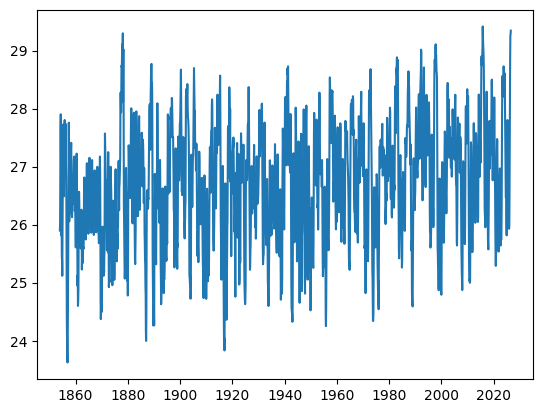

In [4]:
# ---- plot all the data --
plt.plot(df["time"],df["nino34"])

- Test whether the characteristics of Niño 3.4 in recent decades (1996–2025) have changed from the earlier period (1951–1980).


In [5]:
### organize the data
### define the two period

early = df.loc[(df["year"] >= 1951) & (df["year"] <= 1980), "nino34"].values
recent = df.loc[(df["year"] >= 1996) & (df["year"] <= 2025), "nino34"].values

print("Early period 1951-1980: n =", len(early),
      "mean =", early.mean(), "std =", early.std(ddof=1))
print("Recent period 1996-2025: n =", len(recent),
      "mean =", recent.mean(), "std =", recent.std(ddof=1))


Early period 1951-1980: n = 360 mean = 26.743776250000003 std = 0.9123559696233714
Recent period 1996-2025: n = 360 mean = 26.995492416666668 std = 1.0238408991708086


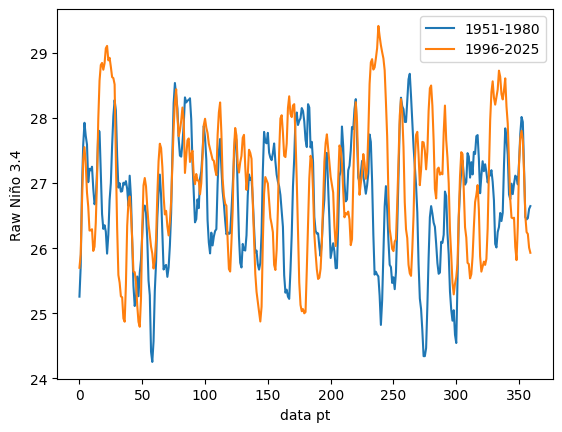

In [6]:
plt.plot(early,label='1951-1980')
plt.plot(recent,label='1996-2025')
plt.legend()
plt.xlabel('data pt')
plt.ylabel('Raw Niño 3.4')
plt.savefig('nino34.png',dpi=200)

### 1. If mean has changed: Welch's t-test
scipy.stats.ttest_ind

In [7]:
t_stat, p_val = stats.ttest_ind(recent, early, equal_var=False)
print (f"Welch's t-test: {t_stat:.2f};", f"p-value: {p_val:.3g}")

Welch's t-test: 3.48; p-value: 0.000527


In [8]:
results=stats.ttest_ind(recent, early,equal_var=False)
results

TtestResult(statistic=np.float64(3.482644213825185), pvalue=np.float64(0.0005269720119267205), df=np.float64(708.664044962977))

### 2. If varainces from the two periods are the same: F-test

Scipy.stats doesn't offer F-test of equal variances, so we will do the calculation direclty.

$$
F = \dfrac{\sigma_1^2}{\sigma_2^2}
$$

In [9]:
# F-statistic
n1, n2 = len(recent), len(early)
sigma1, sigma2 = recent.std(ddof=1), early.std(ddof=1)
F = sigma1**2 / sigma2**2       # convention: larger-variance group in numerator is optional;
dfn, dfd = n1 - 1, n2 - 1      # here it's just recent/early as defined
print(f"F = {F:.4f}, df=({dfn},{dfd})")


F = 1.2593, df=(359,359)


We need to find the p-value given F and the degrees of freedom.

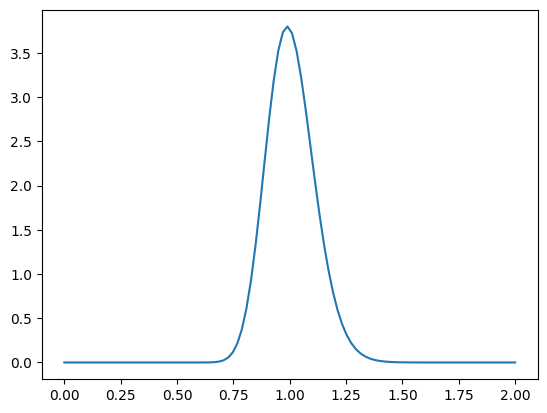

In [10]:
xs = np.linspace(0, 2, 100)
ys = stats.f.pdf(xs, dfn, dfd)
plt.plot(xs, ys)

But we don't know whether our observed value is on the left or right side, so let's check both and get the two-tailed p-value by doubling the smaller tail.

In [11]:
p_lower = stats.f.cdf(F, dfn, dfd)
p_upper = 1 - stats.f.cdf(F, dfn, dfd)
p_val = 2 * min(p_upper, p_lower)

print(f" p = {p_val:.4g}")


 p = 0.02923


### Correlation test

- use pearson

In [15]:
rho, p_scipy = stats.pearsonr(early, recent)
print(f" coreelation: {rho:.2f}, p = {p_scipy:.4g}")





 coreelation: 0.12, p = 0.02478


--- back to the lecture

### Hands on ###
- load and organize PRISM monthly temperature and precip data for Oregan

In [16]:
df=pd.read_csv('/content/PRISM_ppt_tmean_45.0000_-123.0000_189501_202607.csv')
df


,Date,ppt (inches),tmean (degrees F)
0,1895-01,11.60,38.3
1,1895-02,1.77,42.5
2,1895-03,4.24,44.6
3,1895-04,2.71,51.5
4,1895-05,4.63,55.3
...,...,...,...
1574,2026-03,3.09,49.1
1575,2026-04,3.11,52.7
1576,2026-05,0.60,59.6
1577,2026-06,0.97,64.4


In [17]:
df.columns = ['date', 'ppt', 'tmean']
df['year'] = df['date'].str[:4].astype(int)
df['month'] = df['date'].str[5:7].astype(int)
df

,date,ppt,tmean,year,month
0,1895-01,11.60,38.3,1895,1
1,1895-02,1.77,42.5,1895,2
2,1895-03,4.24,44.6,1895,3
3,1895-04,2.71,51.5,1895,4
4,1895-05,4.63,55.3,1895,5
...,...,...,...,...,...
1574,2026-03,3.09,49.1,2026,3
1575,2026-04,3.11,52.7,2026,4
1576,2026-05,0.60,59.6,2026,5
1577,2026-06,0.97,64.4,2026,6


In [18]:
# Aggregate to annual: mean temperature, total precipitation
annual_temp = df.groupby('year')['tmean'].mean()
annual_ppt = df.groupby('year')['ppt'].sum()

### define the two period:
arg_early = np.argwhere((annual_temp.index>=1951) & (annual_temp.index<=1980)).ravel()
arg_recent = np.argwhere((annual_temp.index>=1996) & (annual_temp.index<=2025)).ravel()

t1 = annual_temp.values[arg_early]
t2 = annual_temp.values[arg_recent]
p1 = annual_ppt.values[arg_early]
p2 = annual_ppt.values[arg_recent]


Now, lets do the tests!

In [19]:
## for f-test
def f_test(x1, x2):
    f_stat = x2.var(ddof=1) / x1.var(ddof=1)
    dfn, dfd = len(x2) - 1, len(x1) - 1
    p_f = 2 * min(stats.f.cdf(f_stat, dfn, dfd), 1 - stats.f.cdf(f_stat, dfn, dfd))
    return f_stat,dfn,dfd,p_f

In [20]:
## for temperature
t_stat,p_t = stats.ttest_ind(t1,t2, equal_var=False)
f_stat,dfn,dfd,p_f = f_test(t1,t2)
print("for temperature")
print(f"T-test: t={t_stat:.4f}, df={len(t1)+len(t2)-2}, p={p_t:.4f}")
print(f"F-test: F={f_stat:.4f}, df1={dfn}, df2={dfd}, p={p_f:.4f}")

for temperature
T-test: t=-5.3479, df=58, p=0.0000
F-test: F=1.1907, df1=29, df2=29, p=0.6415


In [21]:

## for precipitaiton
t_stat,p_t = stats.ttest_ind(p1,p2, equal_var=False)
f_stat,dfn,dfd,p_f = f_test(p1,p2)
print("for precipitation")
print(f"T-test: t={t_stat:.4f}, df={len(t1)+len(t2)-2}, p={p_t:.4f}")
print(f"F-test: F={f_stat:.4f}, df1={dfn}, df2={dfd}, p={p_f:.4f}")

for precipitation
T-test: t=-0.4959, df=58, p=0.6223
F-test: F=2.7310, df1=29, df2=29, p=0.0086


In [22]:
stats.spearmanr(annual_temp.values[arg_early[0]:], annual_ppt.values[arg_early[0]:])

SignificanceResult(statistic=np.float64(0.072321605568676), pvalue=np.float64(0.5346984730607092))